# Trend Signal

The EDA showed a weak but non-zero correlation between Google search interest and future stock returns. This notebook turns that into an actual signal — something that tilts portfolio weights based on what people are currently searching.

The idea: if "quiet luxury" is trending unusually high relative to its recent baseline, overweight LVMH. If "zara haul" is spiking, tilt toward Inditex. The signal adjusts the max-Sharpe weights rather than replacing them.

In [25]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from scipy.optimize import minimize

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

TICKER_LABELS = {
    'MC.PA'   : 'LVMH',
    'ITX.MC'  : 'Inditex',
    'HM-B.ST' : 'H&M',
    'TPR'     : 'Tapestry',
}

SIGNAL_MAP = {
    'quiet luxury' : 'LVMH',
    'zara haul'    : 'Inditex',
    'streetwear'   : 'H&M',
}

prices = pd.read_csv('data/prices.csv', index_col=0, parse_dates=True)
trends = pd.read_csv('data/trends.csv', index_col=0, parse_dates=True)


prices.columns = [TICKER_LABELS.get(c, c) for c in prices.columns]

if trends.empty:
    raise ValueError('trends.csv is empty — re-run 01_data_collection.ipynb.')

# monthly or weekly data
freq_days  = (trends.index[1] - trends.index[0]).days
IS_MONTHLY = freq_days > 14
FREQ_LABEL = 'months' if IS_MONTHLY else 'weeks'
RESAMPLE   = 'ME'     if IS_MONTHLY else 'W'
WINDOW     = 6        if IS_MONTHLY else 12
ROLL_WIN   = 12       if IS_MONTHLY else 26

print(f'Trends frequency: {FREQ_LABEL}  ({freq_days} days between observations)')
print(f'Rolling window: {WINDOW} {FREQ_LABEL}')
print(f'Prices shape: {prices.shape}')
print(f'Trends shape: {trends.shape}')

# only signal columns
SIGNAL_MAP = {k: v for k, v in SIGNAL_MAP.items() if k in trends.columns}
print(f'Active signals: {SIGNAL_MAP}')

Trends frequency: months  (31 days between observations)
Rolling window: 6 months
Prices shape: (1550, 4)
Trends shape: (72, 3)
Active signals: {'quiet luxury': 'LVMH', 'zara haul': 'Inditex', 'streetwear': 'H&M'}


## 1. Signal Construction

Raw Trends values (0 - 100 ) aren't directly useful because they're scaled to the peak within the full period, not to what's "normal" recently. A score of 40 means something different if the recent baseline is 20 vs 38.

I'm using a rolling z-score. How many standard deviations above or below the recent baseline is this period's search interest?

$$z_t = \frac{x_t - \mu_{t-W:t}}{\sigma_{t-W:t}}$$

Columns that are near-constant over the whole window (std ≈ 0) get dropped — they carry no signal.

In [26]:
def rolling_zscore(series, window):
    roll_mean = series.rolling(window, min_periods=window).mean()
    roll_std  = series.rolling(window, min_periods=window).std()
    roll_std  = roll_std.where(roll_std > 1e-6, np.nan)   # treat near-zero std as NaN
    return (series - roll_mean) / roll_std


raw_signals = pd.DataFrame(index=trends.index)
for col in trends.columns:
    raw_signals[col] = rolling_zscore(trends[col], WINDOW)

# drop columns that are NaN
usable = raw_signals.columns[raw_signals.notna().any()]
signals = raw_signals[usable].dropna(how='all')

dropped = set(trends.columns) - set(usable)
if dropped:
    print(f'[info] Dropped near-constant keywords (no usable signal): {dropped}')

    SIGNAL_MAP = {k: v for k, v in SIGNAL_MAP.items() if k in usable}

if signals.empty:
    raise ValueError('no signal data')


signals.describe().round(3)
print(f'Signal shape: {signals.shape}')
print(f'Date range: {signals.index[0].date()} → {signals.index[-1].date()}')
print(f'Active pairs: {SIGNAL_MAP}')

Signal shape: (67, 3)
Date range: 2020-06-01 → 2025-12-01
Active pairs: {'quiet luxury': 'LVMH', 'zara haul': 'Inditex', 'streetwear': 'H&M'}


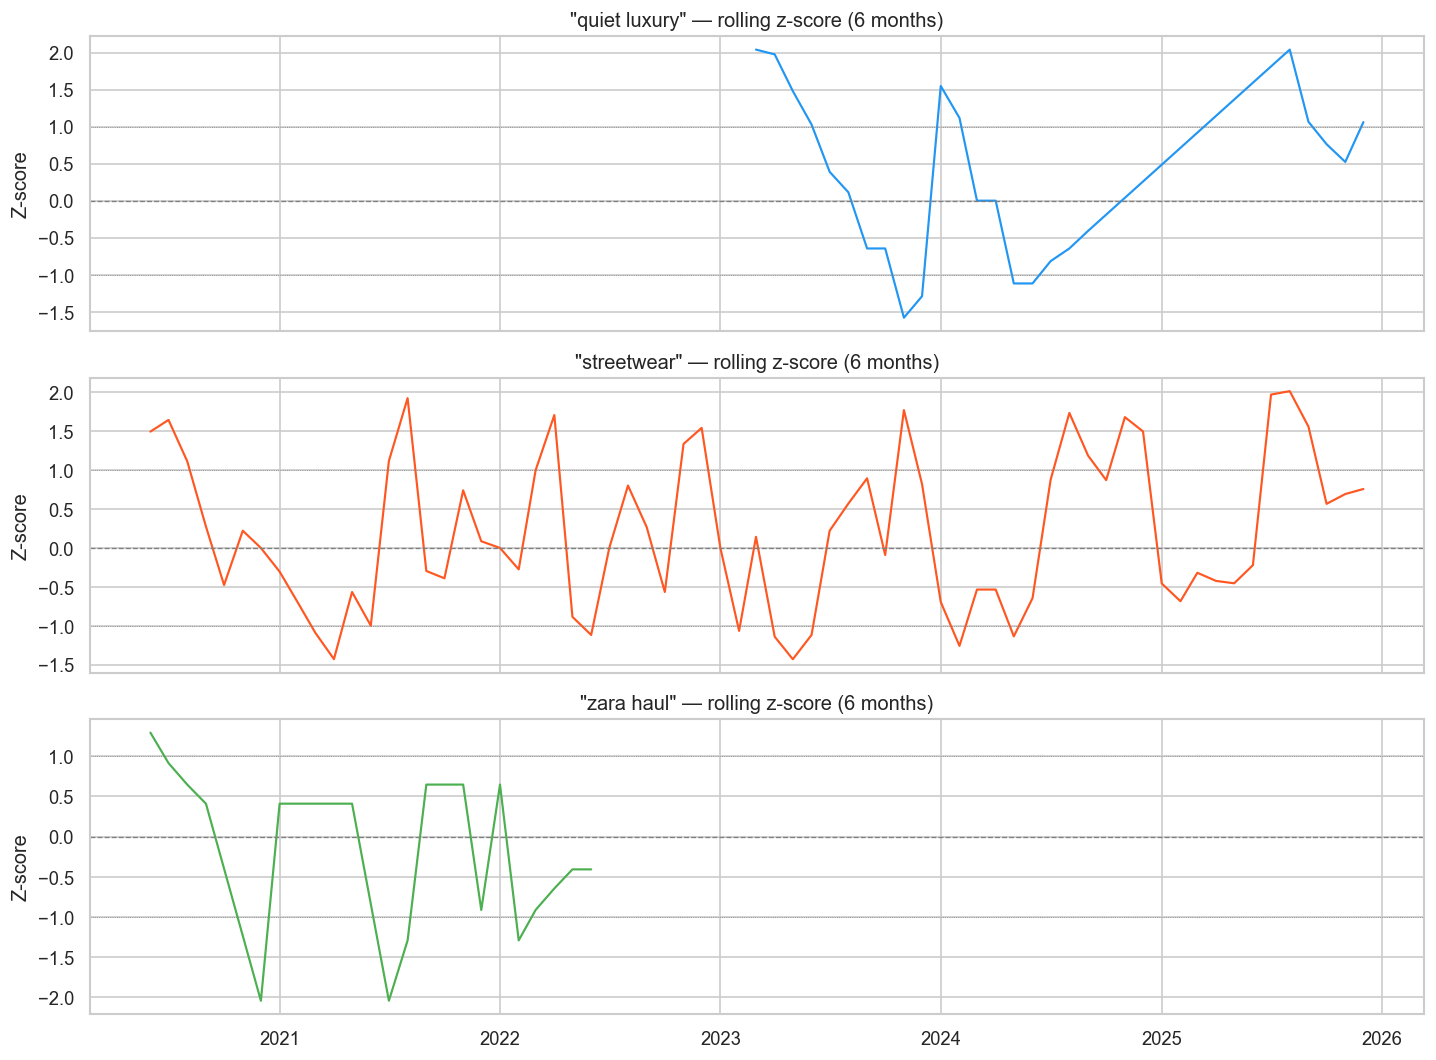

In [27]:
# display rolling z score 
n_kw    = len(signals.columns)
colors  = ['#2196F3', '#FF5722', '#4CAF50']
fig, axes = plt.subplots(n_kw, 1, figsize=(12, 3 * n_kw), sharex=True)
if n_kw == 1:
    axes = [axes]

for ax, col, color in zip(axes, signals.columns, colors):
    s = signals[col].dropna()
    ax.plot(s.index, s, color=color, linewidth=1.3)
    ax.axhline(0,  color='grey', linewidth=0.8, linestyle='--')
    ax.axhline(1,  color='grey', linewidth=0.5, linestyle=':')
    ax.axhline(-1, color='grey', linewidth=0.5, linestyle=':')
    ax.set_ylabel('Z-score')
    ax.set_title(f'"{col}" — rolling z-score ({WINDOW} {FREQ_LABEL})')

axes[-1].xaxis.set_major_locator(mdates.YearLocator())

axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.tight_layout()

plt.show()

## 3. Lead-Lag Analysis

If the signal is useful for prediction, it should correlate with returns at a positive lag - meaning the search spike happens before the price move, not at the same time.

In [28]:
# match trends frequency
period_prices  = prices.resample(RESAMPLE).last()
period_returns = np.log(period_prices / period_prices.shift(1)).dropna()

print(period_returns.round(4))

LAGS = range(-4, 5)


lag_corrs = {}

for keyword, stock in SIGNAL_MAP.items():
    if stock not in period_returns.columns:
        continue
    corrs = []
    for lag in LAGS:
        sig      = signals[keyword].reindex(period_returns.index, method='nearest')
        combined = pd.concat([sig.shift(lag), period_returns[stock]], axis=1).dropna()
        r = combined.corr().iloc[0, 1] if len(combined) > 5 else np.nan
        corrs.append(r)
    lag_corrs[f'"{keyword}" - {stock}'] = corrs

lag_df = pd.DataFrame(lag_corrs, index=list(LAGS))
lag_df.index.name = f'lag ({FREQ_LABEL})'
print(lag_df.round(4))

               H&M  Inditex    LVMH  Tapestry
Date                                         
2020-02-29 -0.1996  -0.0766 -0.0638   -0.0943
2020-03-31 -0.3033  -0.1731 -0.0914   -0.5798
2020-04-30  0.0621  -0.0175  0.0405    0.1389
2020-05-31  0.0428   0.0746  0.0620   -0.0899
2020-06-30 -0.0516  -0.0609  0.0405   -0.0238
...            ...      ...     ...       ...
2025-08-31  0.0479   0.0069  0.0651   -0.0592
2025-09-30  0.2328   0.1071  0.0320    0.1099
2025-10-31  0.0284   0.0368  0.1621   -0.0305
2025-11-30 -0.0313   0.0073  0.0375   -0.0049
2025-12-31  0.0818   0.1600  0.0146    0.1735

[71 rows x 4 columns]
              "quiet luxury" - LVMH  "zara haul" - Inditex  "streetwear" - H&M
lag (months)                                                                  
-4                          -0.1963                -0.1278             -0.1039
-3                          -0.0052                -0.1327             -0.0807
-2                           0.2608                -0.1630     

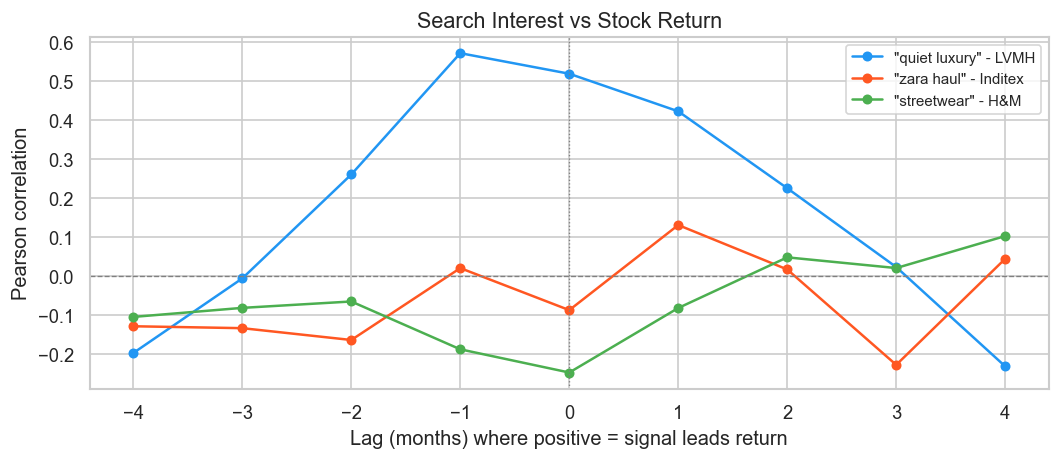

In [29]:
fig, ax = plt.subplots(figsize=(9, 4))
for col, color in zip(lag_df.columns, colors):
    ax.plot(lag_df.index, lag_df[col], marker='o', linewidth=1.5, markersize=5,
            color=color, label=col)
ax.axhline(0, color='grey', linewidth=0.8, linestyle='--')
ax.axvline(0, color='grey', linewidth=0.8, linestyle=':')
ax.set_xlabel(f'Lag ({FREQ_LABEL}) where positive = signal leads return')
ax.set_ylabel('Pearson correlation')
ax.set_title('Search Interest vs Stock Return', fontsize=13)
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

## 4. Rolling Correlation

A single correlation number over the full period hides whether the relationship is stable or just happened to be strong in one stretch. Rolling correlation shows when the signal works and when it doesn't.

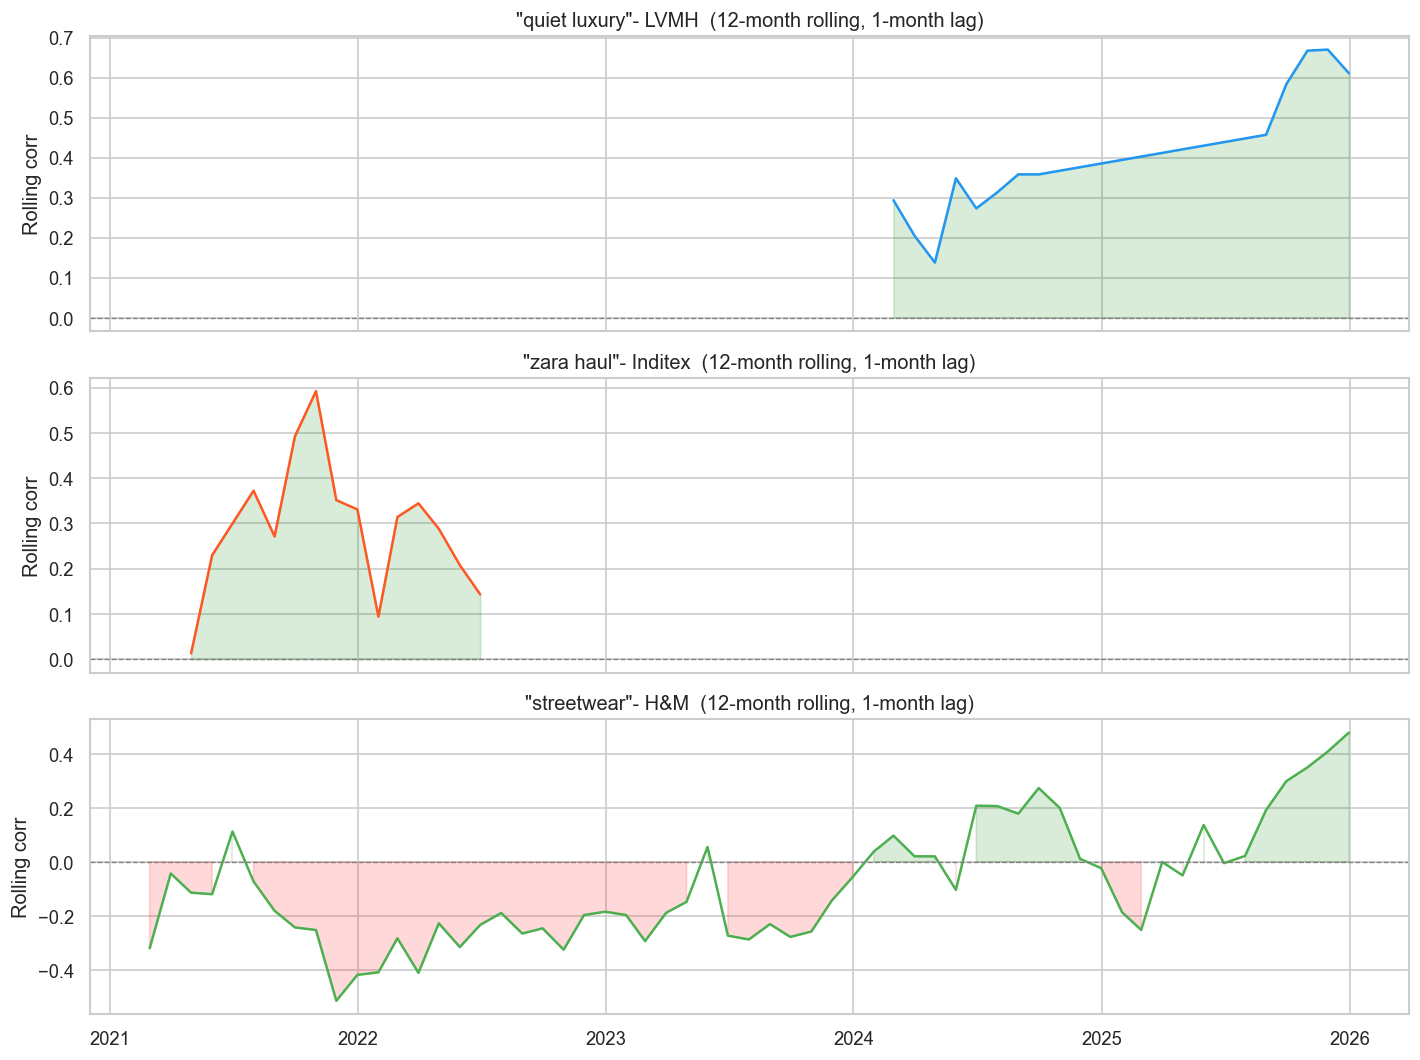

In [30]:
active_pairs = [(k, v) for k, v in SIGNAL_MAP.items() if v in period_returns.columns]

if active_pairs:
    fig, axes = plt.subplots(len(active_pairs), 1,
                             figsize=(12, 3 * len(active_pairs)), sharex=True)
    if len(active_pairs) == 1:
        axes = [axes]

    for ax, (keyword, stock), color in zip(axes, active_pairs, colors):
        sig      = signals[keyword].reindex(period_returns.index, method='nearest').shift(1)
        combined = pd.concat([sig, period_returns[stock]], axis=1).dropna()
        combined.columns = ['signal', 'return']

        roll_corr = combined['signal'].rolling(ROLL_WIN).corr(combined['return'])

        ax.plot(roll_corr.index, roll_corr, color=color, linewidth=1.5)
        ax.axhline(0, color='grey', linewidth=0.8, linestyle='--')
        ax.fill_between(roll_corr.index, roll_corr, 0,
                        where=(roll_corr > 0), alpha=0.15, color='green')
        ax.fill_between(roll_corr.index, roll_corr, 0,
                        where=(roll_corr < 0), alpha=0.15, color='red')
        ax.set_ylabel('Rolling corr')
        ax.set_title(f'"{keyword}"- {stock}  ({ROLL_WIN}-{FREQ_LABEL[:-1]} rolling, 1-{FREQ_LABEL[:-1]} lag)')

    axes[-1].xaxis.set_major_locator(mdates.YearLocator())
    axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    plt.tight_layout()
    plt.show()
else:
    print('no active signal pairs')

## 5. Trend-Adjusted Portfolio Weights

Start from the max-Sharpe portfolio, then tilt each stock's weight up or down based on the current z-score. $\alpha = 0.3$ keeps the tilt conservative - the signal is weak enough that a large tilt would add noise rather than value.

In [31]:
# recompute max-Sharpe (self-contained)
log_returns = np.log(prices / prices.shift(1)).dropna()
mu_arr      = (log_returns.mean() * 252).values
sigma_arr   = (log_returns.cov()  * 252).values
N_ASSETS    = len(prices.columns)
RF_RATE     = 0.04

res = minimize(
    lambda w: -(w @ mu_arr - RF_RATE) / np.sqrt(w @ sigma_arr @ w),
    np.ones(N_ASSETS) / N_ASSETS,
    method='SLSQP',
    bounds=tuple((0, 1) for _ in range(N_ASSETS)),
    constraints={'type': 'eq', 'fun': lambda w: np.sum(w) - 1},
)
w_maxsharpe = res.x
print(w_maxsharpe.round(4))
stock_names = prices.columns.tolist()

print('Max-Sharpe weights:')
for name, w in zip(stock_names, w_maxsharpe):
    print(f'{name}: {w:.4f}')

[0.     0.3887 0.     0.6113]
Max-Sharpe weights:
H&M: 0.0000
Inditex: 0.3887
LVMH: 0.0000
Tapestry: 0.6113


Let's tilt base_w using current z-scores and return re-normalized weights.

In [32]:
ALPHA = 0.3

def trend_adjusted_weights(base_w, stock_names, sig_row, signal_map, alpha=ALPHA):
    w = base_w.copy()
    for keyword, stock in signal_map.items():
        if keyword not in sig_row.index or stock not in stock_names:
            continue
        z = sig_row[keyword]
        if np.isnan(z):
            continue
        idx    = stock_names.index(stock)
        w[idx] *= (1 + alpha * np.clip(z, -2, 2) / 2)
    w = np.clip(w, 0, None)
    return w / w.sum()

print(f'\nExample adjusted weights (last date): {signals.index[-1].date()}')
print (trend_adjusted_weights(w_maxsharpe, stock_names, signals.iloc[-1], SIGNAL_MAP))

adj_weights = np.array([
    trend_adjusted_weights(w_maxsharpe, stock_names, signals.loc[d], SIGNAL_MAP)
    for d in signals.index
])

adj_weights_df = pd.DataFrame(adj_weights, index=signals.index, columns=stock_names)
print(f'\nAdjusted weights shape: {adj_weights_df.shape}')

adj_weights_df.to_csv('data/trend_weights.csv')

print(f'Saved to data/trend_weights.csv({len(adj_weights_df)} rows)')
adj_weights_df.tail()


Example adjusted weights (last date): 2025-12-01
[1.02630549e-16 3.88735798e-01 0.00000000e+00 6.11264202e-01]

Adjusted weights shape: (67, 4)
Saved to data/trend_weights.csv(67 rows)


,H&M,Inditex,LVMH,Tapestry
date,,,,
2025-08-01,1.198043e-16,0.388736,0.0,0.611264
2025-09-01,1.137115e-16,0.388736,0.0,0.611264
2025-10-01,9.999299e-17,0.388736,0.0,0.611264
2025-11-01,1.017356e-16,0.388736,0.0,0.611264
2025-12-01,1.026305e-16,0.388736,0.0,0.611264


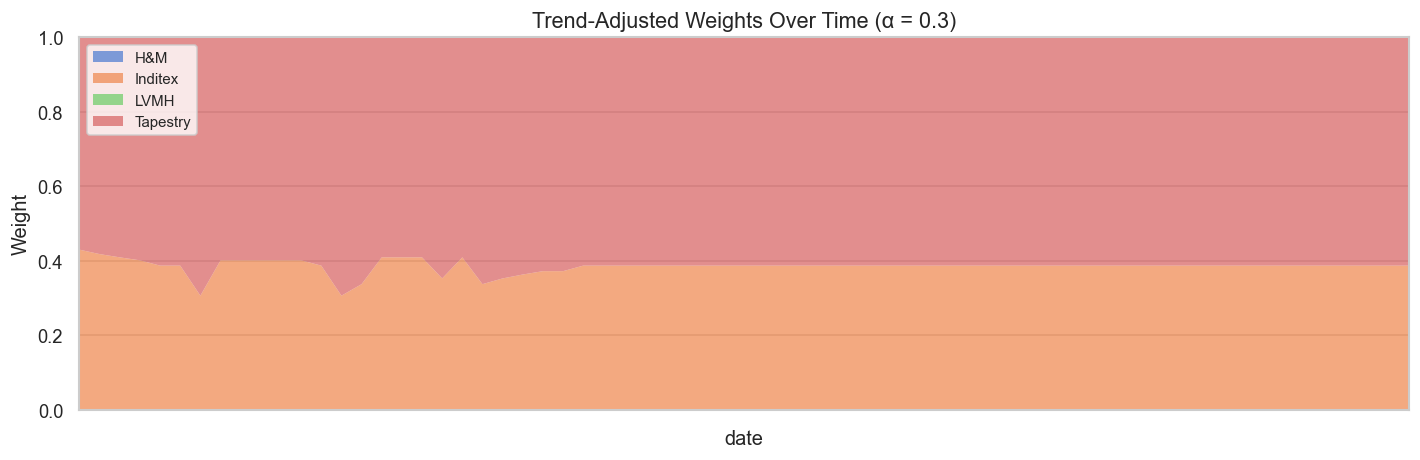

In [33]:
fig, ax = plt.subplots(figsize=(12, 4))
adj_weights_df.plot.area(ax=ax, alpha=0.7, linewidth=0)
ax.set_title(f'Trend-Adjusted Weights Over Time (α = {ALPHA})', fontsize=13)
ax.set_ylabel('Weight')
ax.set_ylim(0, 1)
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.legend(loc='upper left', fontsize=9)
plt.tight_layout()
plt.show()

## Data quality notes

- "quiet luxury" had near-zero search volume before 2023. The term wasn't popular until then, so LVMH has a meaningful signal only for the last ~2 years of the period.
- "zara haul" has very low variance throughout, contributing minimal tilt.
- "streetwear" is the most stable keyword and produces the most consistent z-scores.
- pytrends returns monthly data for 5+ year ranges. Each "weekly" weight in the backtest is based on monthly search data, which reduces timing precision.

Tapestry is uncovered
- Tapestry has no mapped keyword and always receives only the base max-Sharpe weight. A richer signal would add "Coach handbag" or "Tapestry brand" as terms.

Monotonic signal-return relationship. 
- The z-score tilt assumes higher search interest predicts higher returns for the associated stock. That's a simplification — interest spikes can be driven by bad news ("Zara recall") as much as by positive consumer enthusiasm.